# Multi-Touch Marketing Attribution & ROI Analysis

## Objective
The objective of this analysis is to evaluate marketing campaign performance across multiple channels, identify key revenue drivers, analyze customer acquisition efficiency, and generate actionable insights for ROI optimization.

This exploratory data analysis serves as the foundation for attribution modeling, KPI calculation, and dashboard development.

 ## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

Purpose

The required libraries are imported for data manipulation, statistical analysis, and visualization.

 ## Load Dataset

In [14]:
campaign = pd.read_csv("marketing_campaign_performance_10000.csv")
ads = pd.read_csv("global_ads_performance_dataset-selected-columns.csv")

## Dataset Description

Dataset 1 contains campaign-level performance metrics including impressions, clicks, conversions, cost, revenue, and ROI.

Dataset 2 contains advertising platform performance metrics including CTR, CPC, impressions, clicks, and ad spend across industries and countries.

## Data Dictionary

### Campaign Dataset

- CampaignID: Unique campaign identifier
- StartDate: Campaign start date
- EndDate: Campaign end date
- Channel: Marketing channel
- Impressions: Number of ad views
- Clicks: Number of user clicks
- Leads: Number of generated leads
- Conversions: Number of successful conversions
- Cost_USD: Campaign expenditure
- Revenue_USD: Revenue generated
- ROI: Return on Investment

### Advertising Dataset

- Platform: Advertising platform
- Campaign Type: Marketing campaign category
- Industry: Industry sector
- Country: Geographic market
- CTR: Click Through Rate
- CPC: Cost Per Click
- Ad Spend: Total advertising spend

## Dataset Dimensions

In [15]:
print("Campaign Dataset Shape:", campaign.shape)
print("Ads Dataset Shape:", ads.shape)

Campaign Dataset Shape: (10000, 11)
Ads Dataset Shape: (1800, 10)


### Observation

The campaign dataset contains 10,000 observations and represents campaign-level marketing performance.

The advertising dataset contains 1,800 observations representing cross-platform advertising activities.

In [16]:
campaign.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,13-04-2025,19-04-2025,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,15-12-2025,24-12-2025,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,28-09-2025,06-10-2025,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,17-04-2025,30-04-2025,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,13-03-2025,22-03-2025,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [17]:
ads.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77


## Data Structure Assessment

In [18]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


In [19]:
ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   object 
 1   platform       1800 non-null   object 
 2   campaign_type  1800 non-null   object 
 3   industry       1800 non-null   object 
 4   country        1800 non-null   object 
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 140.8+ KB


Observation

Initial inspection reveals a mixture of numerical, categorical, and date-related variables.

Date columns are currently stored as object data types and require conversion for temporal analysis.

In [20]:
campaign.describe()

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576
std,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806
min,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000
25%,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000
50%,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000
75%,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000
max,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000


In [21]:
ads.describe()

,impressions,clicks,CTR,CPC,ad_spend
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,102919.018889,3962.675556,0.038427,1.572756,6171.527272
std,55740.900690,2941.858037,0.017082,0.800872,5776.996958
min,5059.000000,91.000000,0.008900,0.280000,58.000000
25%,54948.000000,1678.000000,0.025400,0.950000,1966.587500
50%,103653.000000,3318.000000,0.035550,1.460000,4393.860000
75%,150470.250000,5628.000000,0.049800,2.050000,8455.830000
max,199650.000000,16660.000000,0.095600,3.950000,38453.320000


 ## Missing Value Analysis

In [22]:
campaign.isnull().sum()

,0
CampaignID,0
StartDate,0
EndDate,0
Channel,0
Impressions,0
Clicks,0
Leads,0
Conversions,0
Cost_USD,0
Revenue_USD,0


In [23]:
ads.isnull().sum()

,0
date,0
platform,0
campaign_type,0
industry,0
country,0
impressions,0
clicks,0
CTR,0
CPC,0
ad_spend,0


Observation

No missing values were detected in either dataset.

The datasets exhibit high data quality and require minimal preprocessing before analysis.

## Duplicates Analysis

In [24]:
campaign.duplicated().sum()

np.int64(0)

In [25]:
ads.duplicated().sum()

np.int64(0)

observation

No duplicates records were identified.

This indicates that each observation represents a unique marketing activity or campaign instance.

## Data Conversion

In [26]:
campaign['StartDate'] = pd.to_datetime(campaign['StartDate'])
campaign['EndDate'] = pd.to_datetime(campaign['EndDate'])

ads['date'] = pd.to_datetime(ads['date'])

/tmp/ipykernel_6705/1300795297.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  campaign['StartDate'] = pd.to_datetime(campaign['StartDate'])
/tmp/ipykernel_6705/1300795297.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  campaign['EndDate'] = pd.to_datetime(campaign['EndDate'])


##Feature Engineering

Feature engineering is performed to create additional business metrics that support marketing performance evaluation and ROI analysis.

In [39]:
campaign['Campaign_Duration'] = (
    campaign['EndDate'] -
    campaign['StartDate']
).dt.days

campaign[['CampaignID',
          'StartDate',
          'EndDate',
          'Campaign_Duration']].head()

,CampaignID,StartDate,EndDate,Campaign_Duration
0,CAMP00001,2025-04-13,2025-04-19,6
1,CAMP00002,2025-12-15,2025-12-24,9
2,CAMP00003,2025-09-28,2025-10-06,8
3,CAMP00004,2025-04-17,2025-04-30,13
4,CAMP00005,2025-03-13,2025-03-22,9


### Campaign Duration Analysis

Campaign duration represents the number of days a campaign remained active.

This feature will help analyze whether campaign length influences conversions, revenue generation, and

observation

Data fields were successfully converted to datatime format, enabling campaign duration analysis and time-based performance evaluation.

In [27]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CampaignID   10000 non-null  object        
 1   StartDate    10000 non-null  datetime64[ns]
 2   EndDate      10000 non-null  datetime64[ns]
 3   Channel      10000 non-null  object        
 4   Impressions  10000 non-null  int64         
 5   Clicks       10000 non-null  int64         
 6   Leads        10000 non-null  int64         
 7   Conversions  10000 non-null  int64         
 8   Cost_USD     10000 non-null  float64       
 9   Revenue_USD  10000 non-null  float64       
 10  ROI          10000 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(2)
memory usage: 859.5+ KB


In [28]:
ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1800 non-null   datetime64[ns]
 1   platform       1800 non-null   object        
 2   campaign_type  1800 non-null   object        
 3   industry       1800 non-null   object        
 4   country        1800 non-null   object        
 5   impressions    1800 non-null   int64         
 6   clicks         1800 non-null   int64         
 7   CTR            1800 non-null   float64       
 8   CPC            1800 non-null   float64       
 9   ad_spend       1800 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 140.8+ KB


## CTR

In [30]:
campaign['CTR'] = (
    campaign['Clicks'] /
    campaign['Impressions']
) * 100

## Conversion Rate

In [31]:
campaign['Conversion_Rate'] = (
    campaign['Conversions'] /
    campaign['Clicks']
) * 100

## CAC

In [32]:
campaign['CAC'] = (
    campaign['Cost_USD'] /
    campaign['Conversions']
)

### Business Metric Definitions

CTR (Click Through Rate) measures the effectiveness of marketing creatives.

Conversion Rate measures the ability of campaigns to convert clicks into customers.

CAC (Customer Acquisition Cost) measures the average cost required to acquire a customer.

Campaign Duration provides insight into campaign lifecycle performance.

## KPI Summary

In [33]:
campaign[['CTR',
          'Conversion_Rate',
          'CAC',
          'ROI']].describe()

,CTR,Conversion_Rate,CAC,ROI
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.462189,12.094015,10.247006,1.001576
std,2.601789,5.921702,31.511206,0.578806
min,1.000100,2.054795,0.021786,0.000000
25%,3.240441,7.410439,1.324412,0.500000
50%,5.441011,11.066936,3.266165,0.990000
75%,7.707935,16.084263,8.450725,1.510000
max,9.998987,29.890220,1225.450000,2.000000


### Observation

Descriptive statistics provide an overview of campaign efficiency, customer acquisition costs, and profitability distribution across all marketing channels.

## Correlation Analysis

In [40]:
campaign[['Impressions',
          'Clicks',
          'Leads',
          'Conversions',
          'Cost_USD',
          'Revenue_USD',
          'ROI']].corr()

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
Impressions,1.000000,0.719330,0.615934,0.566806,-0.021056,-0.015958,0.009158
Clicks,0.719330,1.000000,0.851751,0.786610,-0.014865,-0.006921,0.015015
Leads,0.615934,0.851751,1.000000,0.920206,-0.012583,-0.004509,0.022152
Conversions,0.566806,0.786610,0.920206,1.000000,-0.016001,-0.006510,0.020949
Cost_USD,-0.021056,-0.014865,-0.012583,-0.016001,1.000000,0.859691,-0.007188
Revenue_USD,-0.015958,-0.006921,-0.004509,-0.006510,0.859691,1.000000,0.438801
ROI,0.009158,0.015015,0.022152,0.020949,-0.007188,0.438801,1.000000


observation

The correlation matrix highlights relationships among marketing metrics and helps identify factors influencing campaign performance.

## Channel Performance Summary

In [41]:
channel_summary = campaign.groupby('Channel').agg({
    'Revenue_USD':'sum',
    'Cost_USD':'sum',
    'Conversions':'sum',
    'ROI':'mean'
}).round(2)

channel_summary.sort_values(
    by='Revenue_USD',
    ascending=False
)

,Revenue_USD,Cost_USD,Conversions,ROI
Channel,,,,
Display,10715125.21,5343184.30,2057607,1.00
Influencer,10558118.99,5278787.92,2101198,1.00
Email,10130542.61,5065029.98,2076423,1.01
Search,9897677.79,4916568.46,1951752,1.01
Social,9725024.70,4919999.25,1920020,0.99


 Business Insight

 channel-level aggregatio provides a consolidated view of revenue generation, spending patterns, conversion efficiency, and profitability

## Revenue by Channel

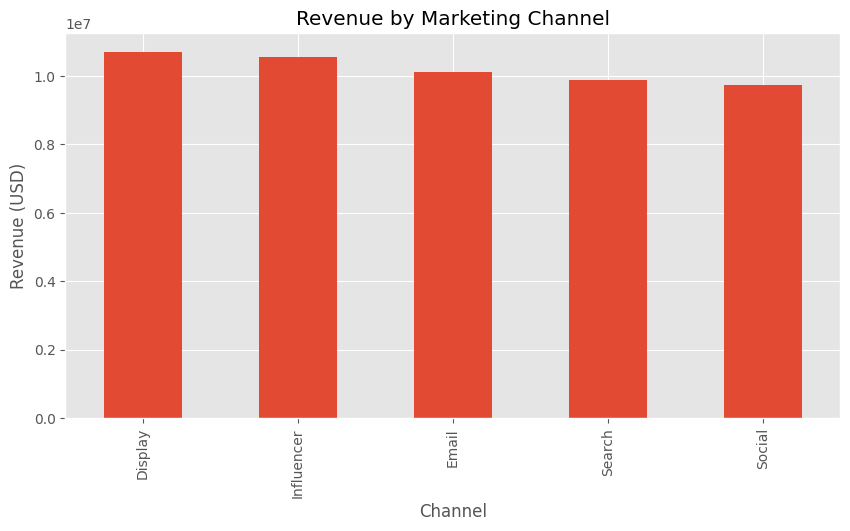

In [34]:
campaign.groupby('Channel')['Revenue_USD'].sum() \
        .sort_values(ascending=False) \
        .plot(kind='bar', figsize=(10,5))

plt.title('Revenue by Marketing Channel')
plt.ylabel('Revenue (USD)')
plt.show()

### Business Insight

This visualization identifies the channel contributing the highest total revenue and highlights the primary revenue drivers within the marketing ecosystem.

### Cost by Channel

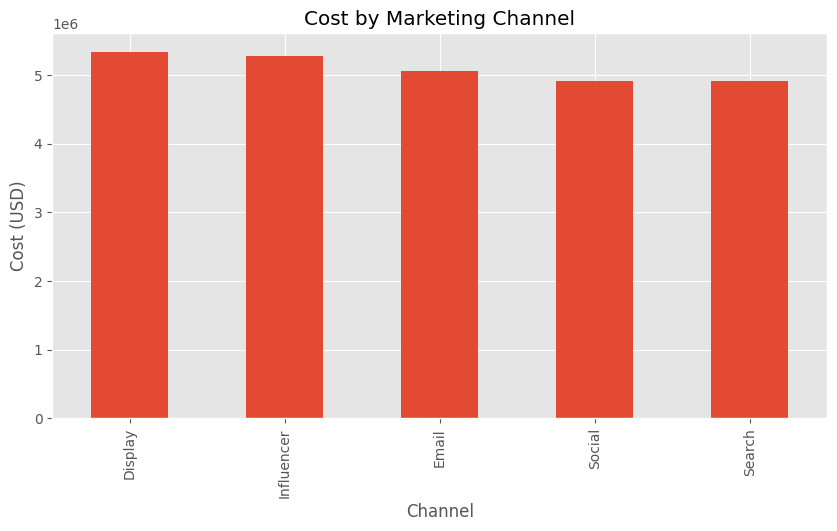

In [35]:
campaign.groupby('Channel')['Cost_USD'].sum() \
        .sort_values(ascending=False) \
        .plot(kind='bar', figsize=(10,5))

plt.title('Cost by Marketing Channel')
plt.ylabel('Cost (USD)')
plt.show()

### Business Insight

Comparing spending patterns across channels helps evaluate budget allocation strategies and identify high-investment marketing channels.

### Conversion by Channel

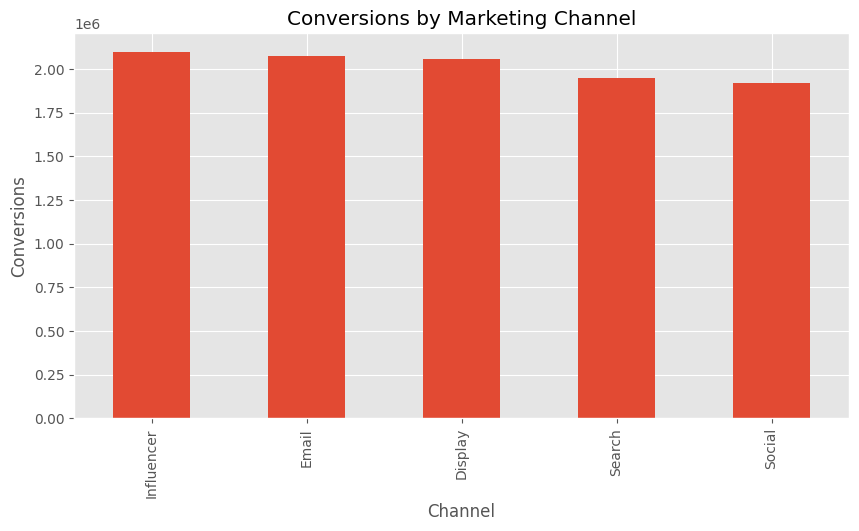

In [36]:
campaign.groupby('Channel')['Conversions'].sum() \
        .sort_values(ascending=False) \
        .plot(kind='bar', figsize=(10,5))

plt.title('Conversions by Marketing Channel')
plt.ylabel('Conversions')
plt.show()

### Business Insight

channel with high conversion volumes stronger customer acquisition performance and may warrent additional investment.

### ROI by Channel

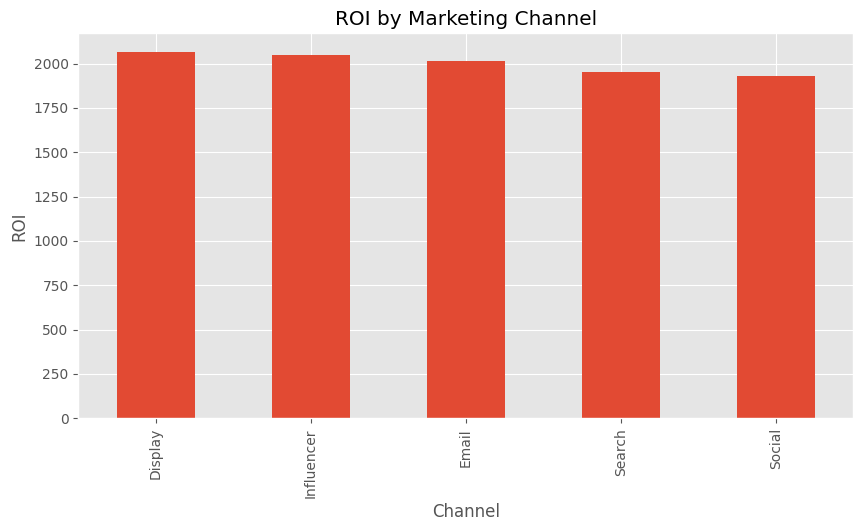

In [37]:
campaign.groupby('Channel')['ROI'].sum() \
        .sort_values(ascending=False) \
        .plot(kind='bar', figsize=(10,5))

plt.title('ROI by Marketing Channel')
plt.ylabel('ROI')
plt.show()

### Business Insight

ROI comparison highlights which marketinh channel generates the highest return relative to spending, supporting data-driven budget optimization.

### Top Performing Campaigns

In [42]:
top_campaigns = campaign.nlargest(
    10,
    'Revenue_USD'
)

top_campaigns[
    ['CampaignID',
     'Channel',
     'Revenue_USD',
     'Cost_USD',
     'ROI']
]

,CampaignID,Channel,Revenue_USD,Cost_USD,ROI
1546,CAMP01547,Search,14871.34,4967.43,1.99
4226,CAMP04227,Display,14801.12,4954.04,1.99
4559,CAMP04560,Display,14692.57,4982.63,1.95
5176,CAMP05177,Display,14683.25,4924.52,1.98
3552,CAMP03553,Search,14659.59,4897.79,1.99
4110,CAMP04111,Influencer,14603.78,4998.16,1.92
3874,CAMP03875,Display,14596.62,4949.24,1.95
5775,CAMP05776,Influencer,14576.50,4974.89,1.93
6681,CAMP06682,Display,14568.71,4857.38,2.00
7473,CAMP07474,Social,14565.88,4872.56,1.99


### Business Insight

Top-performing campaigns representing the highest revenue-generating initiatives and can be used as banchmarks for future marketing strategies.

### Final EDA Summary



1.  No missing values or duplicate records were identified, indicating strong data quality

2. Marketing performance metrics were enriched through feature engineering, including CTR, Conversion Rate, CAC, and Campaign Duration.

3. Revenue, conersion, and ROI analysis revealed significiant variation across marketing channels.

4. Serveral channels demonstrate superior profitability and customer acquisition
efficiency.

5. The findings from this exploratory analysis will serve as the foundation foe attributing modeling, KPI reporting, SQL analysis, and Power BI dashboard development.


